         Iris Flower Species Classification - Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [3]:
# =============================================================
# 1. LOAD DATA
# =============================================================
df = pd.read_csv("Iris.csv")

print("=" * 60)
print("IRIS DATASET - OVERVIEW")
print("=" * 60)
print(df.head(10))
print(f"\nShape     : {df.shape}")
print(f"Columns   : {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nClass distribution:\n{df['Species'].value_counts()}")

IRIS DATASET - OVERVIEW
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
5   6            5.4           3.9            1.7           0.4  Iris-setosa
6   7            4.6           3.4            1.4           0.3  Iris-setosa
7   8            5.0           3.4            1.5           0.2  Iris-setosa
8   9            4.4           2.9            1.4           0.2  Iris-setosa
9  10            4.9           3.1            1.5           0.1  Iris-setosa

Shape     : (150, 6)
Columns   : ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Missing va

In [4]:
# =============================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================
print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(df.describe())


BASIC STATISTICS
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


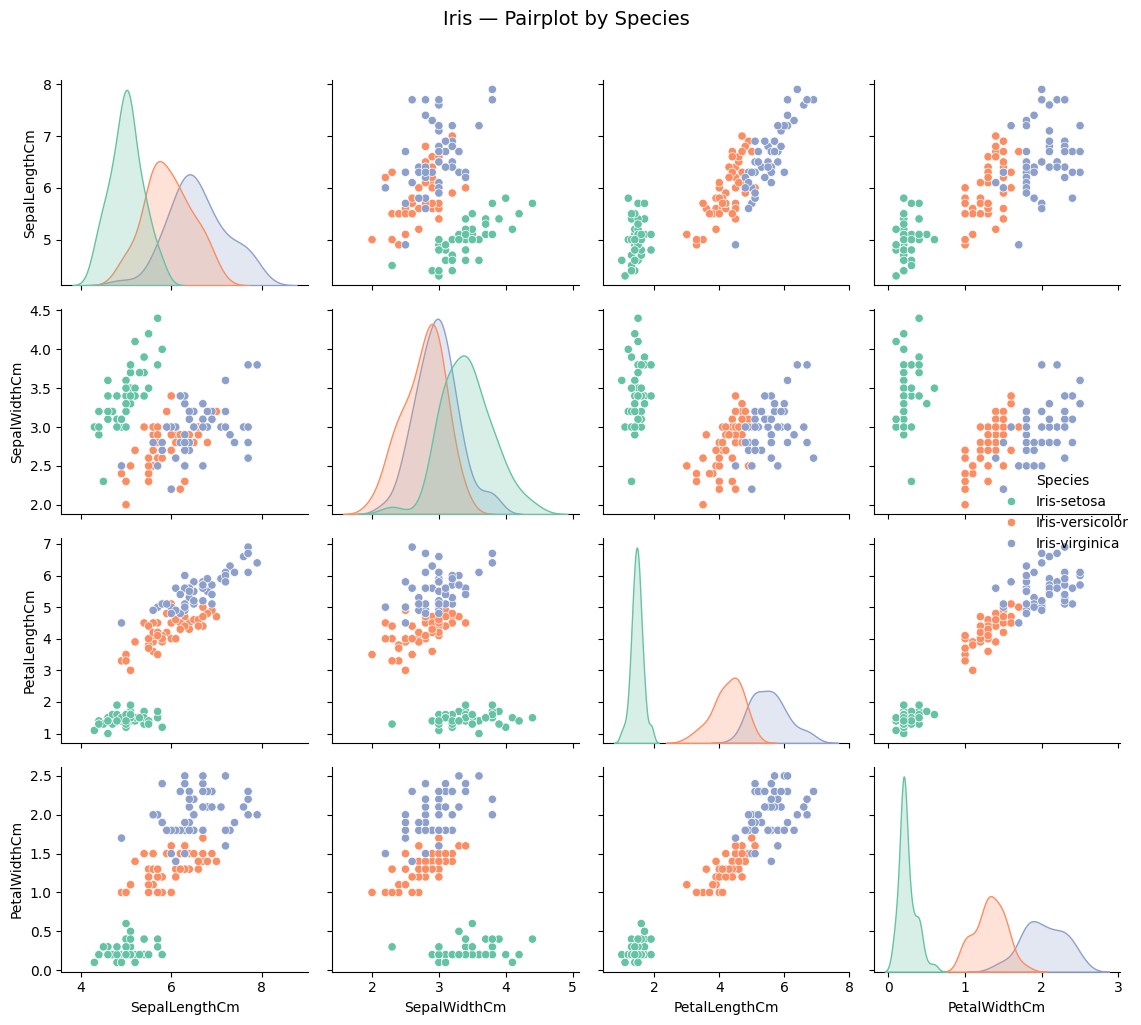

In [7]:
# --- Pairplot ---
sns.pairplot(df.drop('Id', axis=1), hue='Species', palette='Set2')
plt.suptitle("Iris — Pairplot by Species", y=1.02, fontsize=14)
plt.tight_layout()

plt.show()

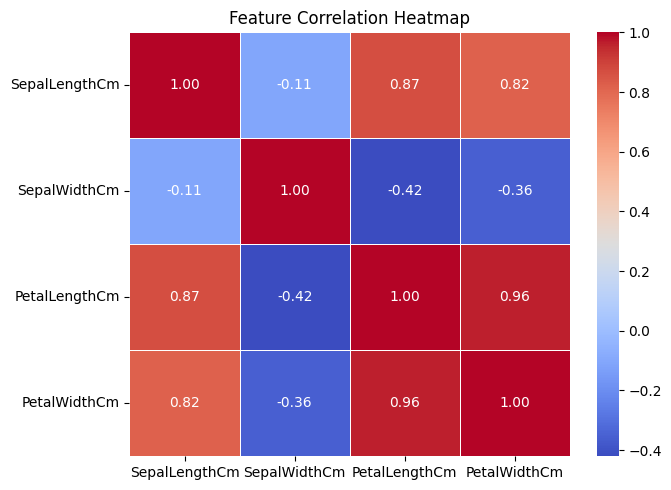

In [8]:
# --- Correlation Heatmap ---
plt.figure(figsize=(7, 5))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

/tmp/ipykernel_11335/1967961303.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y=feat, palette='Set2', ax=ax)
/tmp/ipykernel_11335/1967961303.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y=feat, palette='Set2', ax=ax)
/tmp/ipykernel_11335/1967961303.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y=feat, palette='Set2', ax=ax)
/tmp/ipykernel_11335/1967961303.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

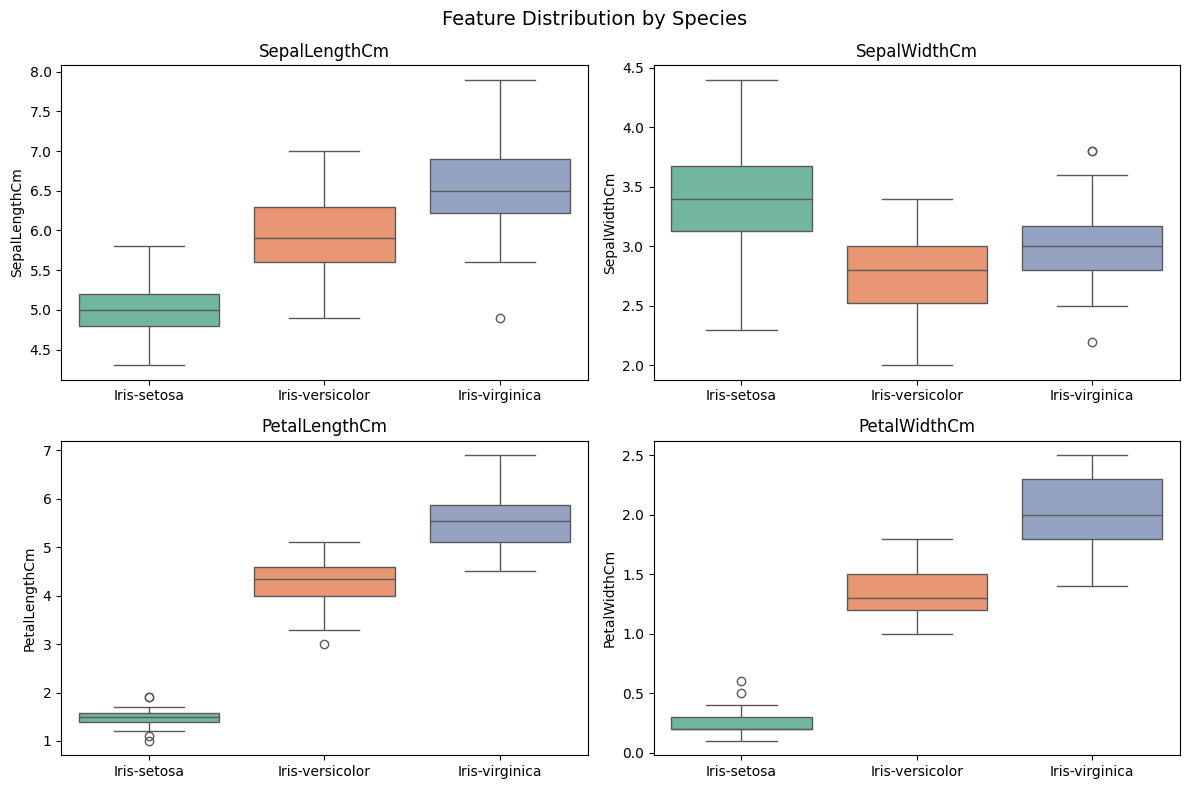

In [9]:
# --- Boxplots per feature ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='Species', y=feat, palette='Set2', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle("Feature Distribution by Species", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# =============================================================
# 3. PREPROCESSING
# =============================================================
# Drop 'Id' column — not a feature
X = df[features]
y = df['Species']

# Encode target: Iris-setosa=0, Iris-versicolor=1, Iris-virginica=2
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nClass encoding : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Train-Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature Scaling (needed for SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


Class encoding : {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}

Training samples : 120
Testing  samples : 30


In [11]:
# =============================================================
# 4. TRAIN & COMPARE MULTIPLE MODELS
# =============================================================
models = {
    "Logistic Regression"  : (LogisticRegression(max_iter=200), True),
    "Decision Tree"        : (DecisionTreeClassifier(random_state=42), False),
    "Random Forest"        : (RandomForestClassifier(n_estimators=100, random_state=42), False),
    "Gradient Boosting"    : (GradientBoostingClassifier(n_estimators=100, random_state=42), False),
    "SVM (RBF)"            : (SVC(kernel='rbf', probability=True), True),
    "K-Nearest Neighbours" : (KNeighborsClassifier(n_neighbors=5), True),
}

print("\n" + "=" * 60)
print("MODEL COMPARISON  —  5-Fold Cross-Validation Accuracy")
print("=" * 60)

cv_results = {}
for name, (model, needs_scaling) in models.items():
    X_cv = X_train_scaled if needs_scaling else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"  {name:<26}  Mean={scores.mean():.4f}   Std={scores.std():.4f}")


MODEL COMPARISON  —  5-Fold Cross-Validation Accuracy
  Logistic Regression         Mean=0.9583   Std=0.0264
  Decision Tree               Mean=0.9417   Std=0.0204
  Random Forest               Mean=0.9500   Std=0.0167
  Gradient Boosting           Mean=0.9667   Std=0.0167
  SVM (RBF)                   Mean=0.9667   Std=0.0312
  K-Nearest Neighbours        Mean=0.9667   Std=0.0312


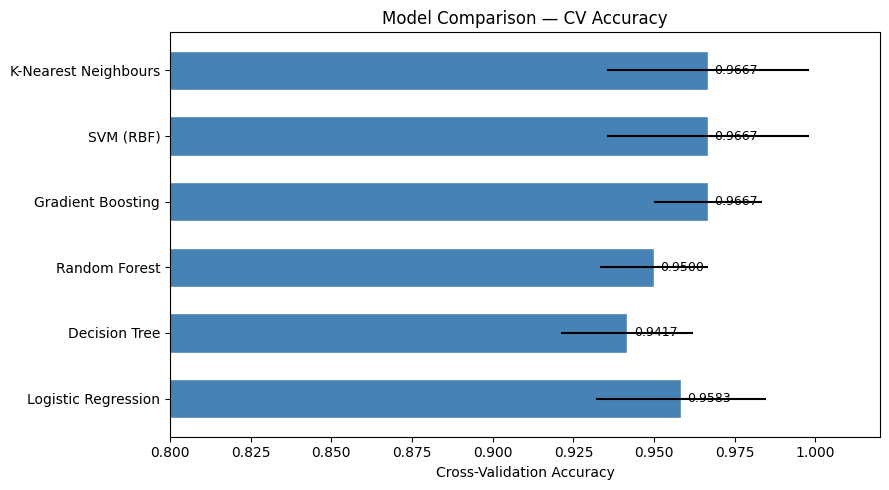

In [13]:
# --- CV Accuracy Bar Chart ---
means = [v.mean() for v in cv_results.values()]
stds  = [v.std()  for v in cv_results.values()]
plt.figure(figsize=(9, 5))
bars = plt.barh(list(cv_results.keys()), means, xerr=stds,
                color='steelblue', edgecolor='white', height=0.6)
plt.xlabel("Cross-Validation Accuracy")
plt.title("Model Comparison — CV Accuracy")
plt.xlim(0.8, 1.02)
for bar, mean in zip(bars, means):
    plt.text(mean + 0.002, bar.get_y() + bar.get_height()/2,
             f"{mean:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
# =============================================================
# 5. BEST MODEL — RANDOM FOREST (full evaluation)
# =============================================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("\n" + "=" * 60)
print("BEST MODEL : Random Forest  —  Test Set Evaluation")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


BEST MODEL : Random Forest  —  Test Set Evaluation
Accuracy : 0.9000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



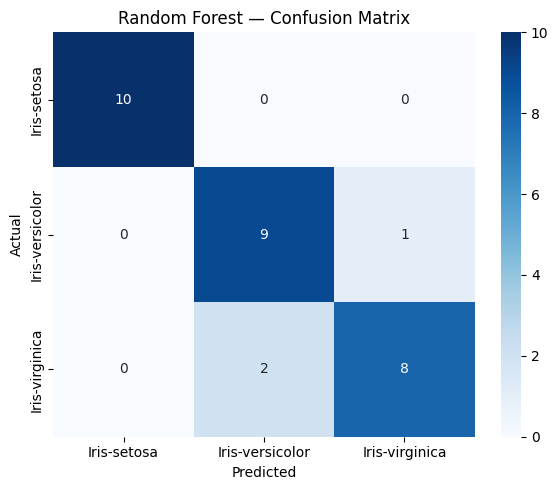

In [15]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Random Forest — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

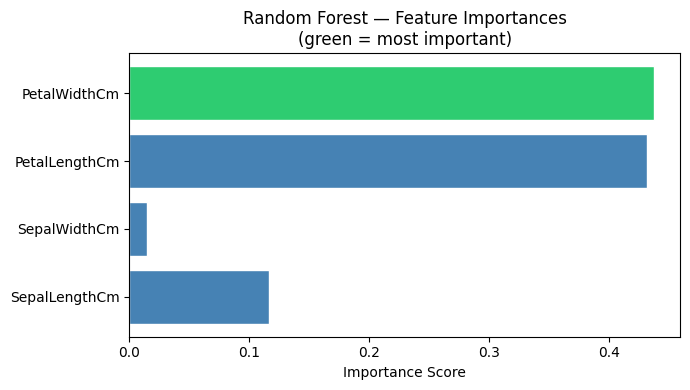

In [16]:
# --- Feature Importance ---
importances = rf_model.feature_importances_
plt.figure(figsize=(7, 4))
colors = ['#2ecc71' if i == importances.argmax() else 'steelblue'
          for i in range(len(features))]
plt.barh(features, importances, color=colors, edgecolor='white')
plt.xlabel("Importance Score")
plt.title("Random Forest — Feature Importances\n(green = most important)")
plt.tight_layout()
plt.show()

In [18]:
# =============================================================
# 6. PREDICT NEW SAMPLES
# =============================================================
print("\n" + "=" * 60)
print("PREDICTING NEW UNSEEN SAMPLES")
print("=" * 60)

new_samples = pd.DataFrame({
    'SepalLengthCm': [5.1, 6.5, 7.2],
    'SepalWidthCm' : [3.5, 2.8, 3.0],
    'PetalLengthCm': [1.4, 4.6, 5.8],
    'PetalWidthCm' : [0.2, 1.5, 2.2],
})

print(new_samples.to_string(index=False))
predictions      = rf_model.predict(new_samples)
pred_proba       = rf_model.predict_proba(new_samples)
predicted_labels = le.inverse_transform(predictions)

print()
for i, (pred, proba) in enumerate(zip(predicted_labels, pred_proba)):
    conf = max(proba) * 100
    print(f"  Sample {i+1}: Predicted = {pred:<20}  Confidence = {conf:.1f}%")

print("\n" + "=" * 60)
print("=" * 60)



PREDICTING NEW UNSEEN SAMPLES
 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
           5.1           3.5            1.4           0.2
           6.5           2.8            4.6           1.5
           7.2           3.0            5.8           2.2

  Sample 1: Predicted = Iris-setosa           Confidence = 100.0%
  Sample 2: Predicted = Iris-versicolor       Confidence = 97.0%
  Sample 3: Predicted = Iris-virginica        Confidence = 100.0%

